In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

print("all libraries imported successfully!")

all libraries imported successfully!


In [8]:
print("loading dataset... please wait")

df = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv', low_memory=False)

print(f"dataset loaded!")
print(f"total rows : {df.shape[0]:,}")
print(f"total columns: {df.shape[1]}")


loading dataset... please wait
dataset loaded!
total rows : 2,260,701
total columns: 151


In [9]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
for i, col in enumerate(df.columns.tolist()):
    print(f"{i+1}. {col}")

1. id
2. member_id
3. loan_amnt
4. funded_amnt
5. funded_amnt_inv
6. term
7. int_rate
8. installment
9. grade
10. sub_grade
11. emp_title
12. emp_length
13. home_ownership
14. annual_inc
15. verification_status
16. issue_d
17. loan_status
18. pymnt_plan
19. url
20. desc
21. purpose
22. title
23. zip_code
24. addr_state
25. dti
26. delinq_2yrs
27. earliest_cr_line
28. fico_range_low
29. fico_range_high
30. inq_last_6mths
31. mths_since_last_delinq
32. mths_since_last_record
33. open_acc
34. pub_rec
35. revol_bal
36. revol_util
37. total_acc
38. initial_list_status
39. out_prncp
40. out_prncp_inv
41. total_pymnt
42. total_pymnt_inv
43. total_rec_prncp
44. total_rec_int
45. total_rec_late_fee
46. recoveries
47. collection_recovery_fee
48. last_pymnt_d
49. last_pymnt_amnt
50. next_pymnt_d
51. last_credit_pull_d
52. last_fico_range_high
53. last_fico_range_low
54. collections_12_mths_ex_med
55. mths_since_last_major_derog
56. policy_code
57. application_type
58. annual_inc_joint
59. dti_joi

In [11]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

print(" loan status count:")
print(df['loan_status'].value_counts())
print(f"\n Default Rate: {(df['loan_status']=='Charged Off').mean()*100:.2f}%")

 loan status count:
loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

 Default Rate: 19.96%


In [13]:
selected_cols = [
    'loan_amnt','int_rate','installment','grade',
    'emp_length','home_ownership','annual_inc', 'purpose',
    'dti', 'fico_range_low','open_acc','pub_rec',
    'revol_bal','revol_util','total_acc','loan_status'
]

df = df[selected_cols].copy()

print(f"columns reduced from 151 to {df.shape[1]}")
print(f"Dataset shape: {df.shape}")

columns reduced from 151 to 16
Dataset shape: (1345310, 16)


In [16]:
missing = df.isnull().sum()
missing_pct = (missing/ len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

            Missing Count  Missing %
emp_length          78511       5.84
revol_util            857       0.06
dti                   374       0.03


In [17]:
df.describe().round(2)

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,open_acc,pub_rec,revol_bal,revol_util,total_acc
count,1345310.00,1345310.00,1345310.00,1345310.00,1344936.00,1345310.00,1345310.00,1345310.00,1345310.00,1344453.00,1345310.00
mean,14419.97,13.24,438.08,76247.64,18.28,696.19,11.59,0.22,16248.11,51.81,24.98
std,8717.05,4.77,261.51,69925.10,11.16,31.85,5.47,0.60,22328.17,24.52,12.00
min,500.00,5.31,4.93,0.00,-1.00,625.00,0.00,0.00,0.00,0.00,2.00
25%,8000.00,9.75,248.48,45780.00,11.79,670.00,8.00,0.00,5943.00,33.40,16.00
50%,12000.00,12.74,375.43,65000.00,17.61,690.00,11.00,0.00,11134.00,52.20,23.00
75%,20000.00,15.99,580.73,90000.00,24.06,710.00,14.00,0.00,19755.75,70.70,32.00
max,40000.00,30.99,1719.83,10999200.00,999.00,845.00,90.00,86.00,2904836.00,892.30,176.00


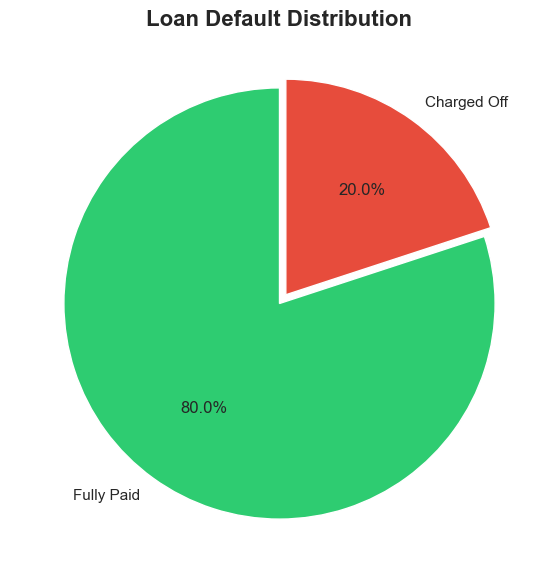

Plot Saved!


In [19]:
status_counts = df['loan_status'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    startangle=90,
    explode=(0,0.05)
)
plt.title('Loan Default Distribution', fontsize=16, fontweight='bold')
plt.savefig('../outputs/01_defaults_distribution.png', bbox_inches='tight')
plt.show()
print("Plot Saved!")

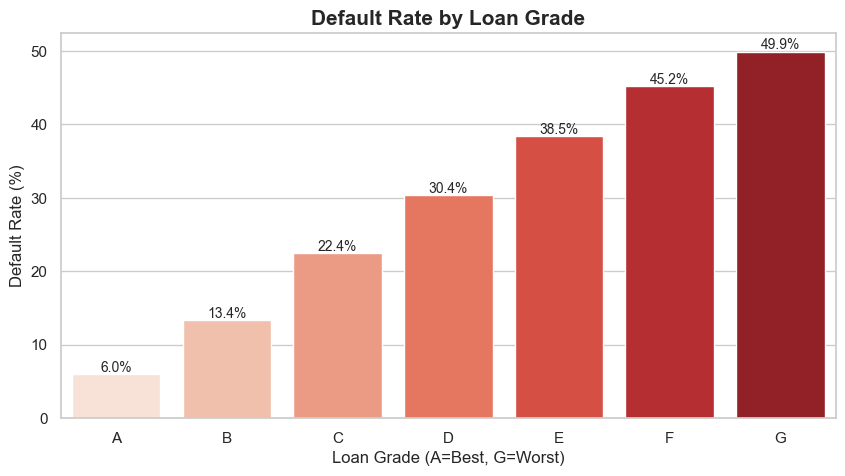

 Plot saved! No warnings!


In [21]:
default_by_grade = df.groupby('grade')['loan_status'].apply(
    lambda x: (x == 'Charged Off').sum() / len(x) * 100
).reset_index()
default_by_grade.columns = ['grade', 'default_rate']

plt.figure(figsize=(10,5))
bars = sns.barplot(
    data=default_by_grade,
    x='grade', y='default_rate',
    hue='grade',
    palette='Reds',
    order=['A','B','C','D','E','F','G'],
    legend=False
)
for bar, val in zip(bars.patches, default_by_grade['default_rate']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.3,
              f'{val:.1f}%', ha='center', fontsize=10)

plt.title('Default Rate by Loan Grade', fontsize=15, fontweight='bold')
plt.xlabel('Loan Grade (A=Best, G=Worst)')
plt.ylabel('Default Rate (%)')
plt.savefig('../outputs/02_default_by_grade.png', bbox_inches='tight')
plt.show()
print(" Plot saved! No warnings!")

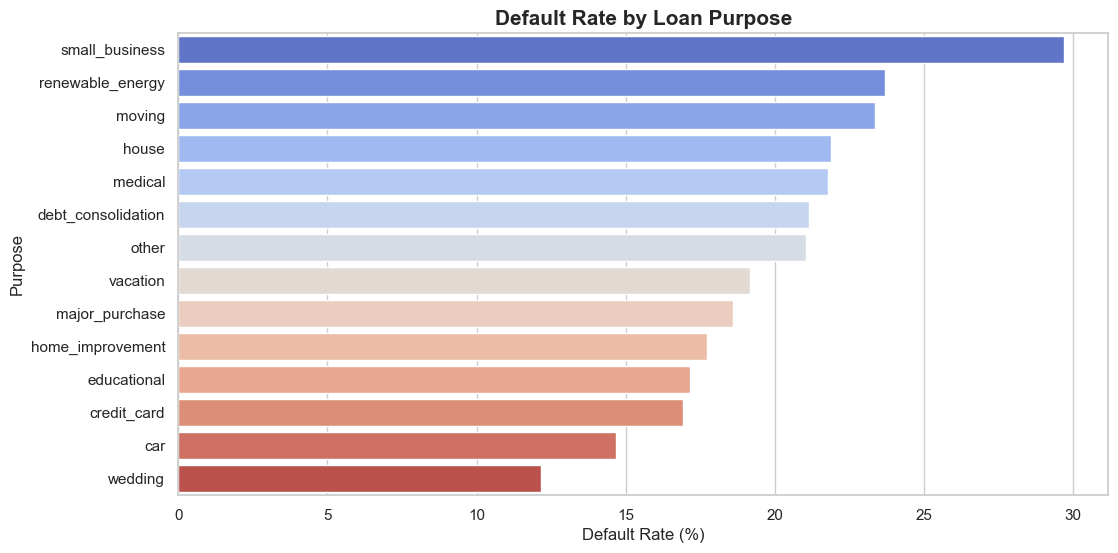

 Plot saved!


In [23]:
default_by_purpose = df.groupby('purpose')['loan_status'].apply(
    lambda x: (x == 'Charged Off').sum() / len(x) * 100
).reset_index()
default_by_purpose.columns = ['purpose', 'default_rate']
default_by_purpose = default_by_purpose.sort_values('default_rate', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=default_by_purpose, x='default_rate', y='purpose',hue='purpose',palette='coolwarm',
legend=False)
plt.title('Default Rate by Loan Purpose', fontsize=15, fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('Purpose')
plt.savefig('../outputs/03_default_by_purpose.png', bbox_inches='tight')
plt.show()
print(" Plot saved!")

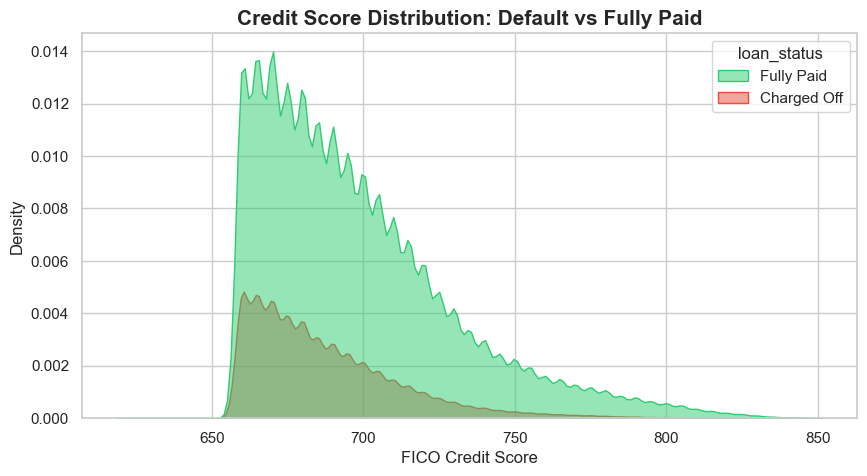

Plot saved!


In [25]:
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=df, x='fico_range_low',
    hue='loan_status',
    fill=True, alpha=0.5,
    palette={'Fully Paid':'#2ecc71', 'Charged Off':'#e74c3c'}
)
plt.title('Credit Score Distribution: Default vs Fully Paid', fontsize=15, fontweight='bold')
plt.xlabel('FICO Credit Score')
plt.ylabel('Density')
plt.savefig('../outputs/04_credit_score_vs_default.png', bbox_inches='tight')
plt.show()
print("Plot saved!")